# Linear regression
We will talk about the most easiest models in machine learning, which is linear regression. 

Also we will talk about gradient descending.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

We will generate some example data.

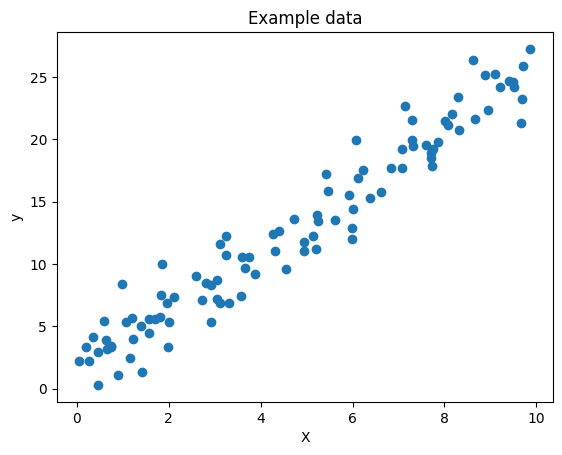

In [10]:
# You can set the seed as you want.
seed = 42
# The true parameters of the linear model.
w_0 = 2.5
b_0 = 1.0
np.random.seed(seed)
X = np.random.rand(100, 1) * 10
y = w_0 * X + b_0 + np.random.randn(100, 1) * 2.0
plt.xlabel('X')
plt.ylabel('y')
plt.title('Example data')
plt.plot(X, y, 'o')

We have generated some random data, there seems to be a linear relationship between x and y. In fact there is, since we generated y from `y = w x + b + noises`.

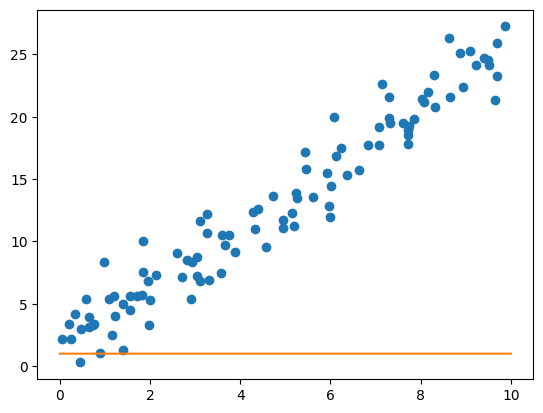

In [76]:
w = 0
b = 1

x_fit = np.linspace(0, 10, 10000)
y_fit = w * x_pred + b

plt.plot(X, y, 'o')
plt.plot(x_fit, y_fit)

Since the dataset is linear, we can draw a line to fit the dataset.

The line is our model, we use it to get an approximate prediction of `y` under certain `x`. It does not seem good.

Machine learning is a bit like teaching a kid.

If he does something wrong, we tell him, and he might do better next time.

But how do we know whether the model is performing well? We use a function called the loss function to measure that.

In [77]:
def loss(X, y, w, b):
    y_pred = (w * X + b)
    return np.mean(y_pred - y)**2

There exists many different loss functions, what we use here is called MSL.

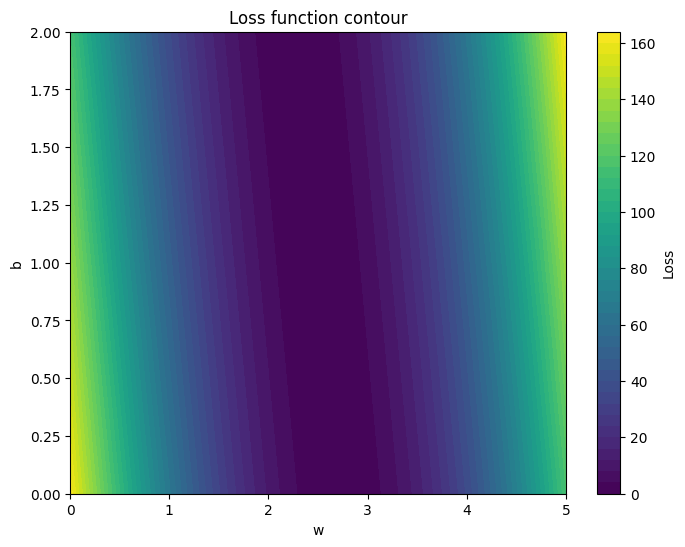

In [78]:
w_range = np.linspace(0, 5, 200)
b_range = np.linspace(0, 2, 200)

W, B = np.meshgrid(w_range, b_range)
L = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        L[i, j] = loss(X, y, W[i, j], B[i, j])

plt.figure(figsize=(8, 6))
cp = plt.contourf(W, B, L, levels=50, cmap='viridis')
plt.colorbar(cp, label='Loss')
plt.xlabel('w')
plt.ylabel('b')
plt.title('Loss function contour')
plt.show()

Since our goal is to find the parameters that minimize the loss, we are going to use gradient descent.

In [79]:
y_pred = w * X + b

w_derivative = np.mean(X.T @ (y_pred - y)) * 2
b_derivative = np.mean(2 * (y_pred - y))

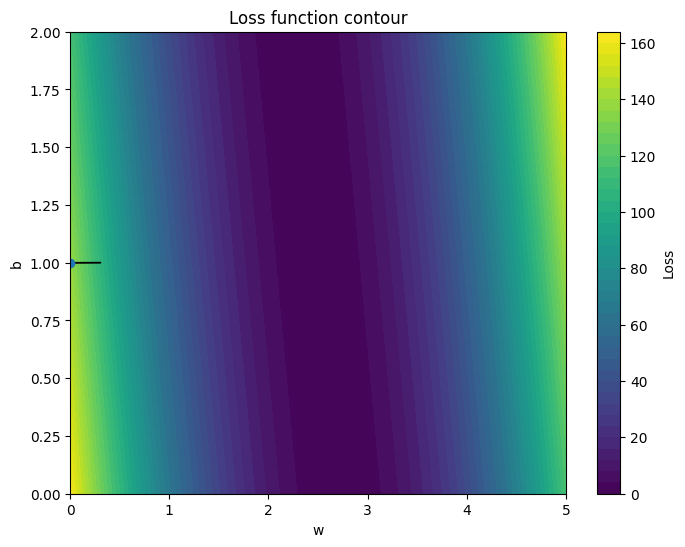

In [82]:
plt.figure(figsize=(8, 6))
cp = plt.contourf(W, B, L, levels=50, cmap='viridis')
plt.colorbar(cp, label='Loss')
plt.xlabel('w')
plt.ylabel('b')
plt.title('Loss function contour')
plt.plot(w, b, 'o')
plt.arrow(w, b, -w_derivative/50000, -b_derivative/50000)
plt.show()

With some simple math, we can compute the partial derivatives and get the gradient of `L(w, b)`. 

The gradient points in the direction where the loss increases the fastest, so the negative gradient points in the direction where the loss decreases the fastest.

In [87]:
w = 0
b = 1

a = 0.0001 # Learning rate
epoch = 1000

for i in range(epoch):
    y_pred = w * X + b
    l = loss(X, y , w, b)

    w_derivative = np.mean(X.T @ (y_pred - y)) * 2
    b_derivative = np.mean(2 * (y_pred - y))

    w -= a * w_derivative
    b -= a * b_derivative
    if (i % 100 == 1): print(l)

20.88343357784316
0.014475409522949564
0.01431202806456567
0.014150490664610783
0.013990776509514058
0.013832865020624818
0.013676735851559211
0.013522368885580524
0.013369744233004872
0.013218842228640023


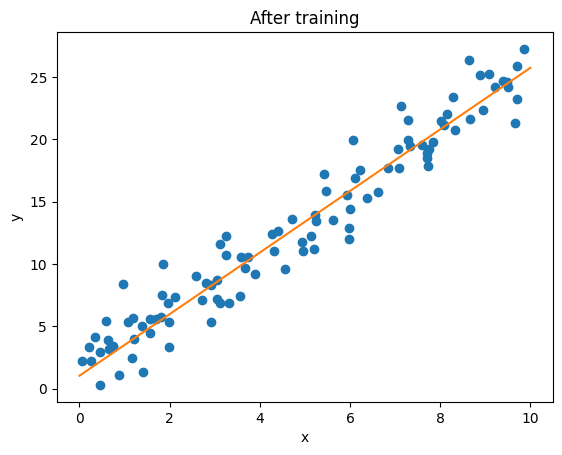

In [90]:
x_fit = np.linspace(0, 10, 10000)
y_fit = w * x_pred + b

plt.xlabel("x")
plt.ylabel("y")
plt.title("After training")
plt.plot(X, y, 'o')
plt.plot(x_fit, y_fit)